# Bispectrum and bicoherence and biphase

## Summary

Bicoherence $b^2$ is a squared, normalized version of the bispectrum. It is real and lies in $[0, 1]$. It measures how much phase coupling / "locking" there is between frequency components. In the following, we consider auto-bispectrum and auto-bicoherence — i.e. the phase coupling between different frequency components in the same signal. The bispectrum and bicoherence can also be computed for 2 different signals.

Throughout this notebook and the accompanying Python code, **bicoherence always means $b^2$** (the Kim–Powers / Elgar–Sebert quantity), not the square-root amplitude $b$. All maps, colorbars, and thresholds are in units of $b^2$.

The strength of the bicoherence is to discover the "hidden signature" of nonlinear processes in a signal. If 3 frequencies $f_1$, $f_2$, $f_3=f_1+f_2$ are present in a signal and visible in its power spectral density (PSD), and $f_3$ is the result of a nonlinear (for example, cross product) interaction between $f_1$ and $f_2$, then $b^2$ will have a peak for the triplet $(f_1, f_2, f_3)$. If there is no peak at this triplet, then $f_3$ is not the result of a nonlinear interaction between $f_1$ and $f_2$. Note that having a bicoherence peak is a necessary, not a sufficient, condition for a non-linear interaction to be present.

## Definitions

### Bispectrum

$B(f_1, f_2) = F(f_1) \, F(f_2) \, F^*(f_1+f_2)$  , with $f_1$ and $f_2$ the 2 frequencies considered, $B$ the bispectrum, $F$ the Fourier transform, $^*$ the complex conjugate.

A $F$ transform results in a complex vector. From standard complex calculations, the $B$ magnitude is the product of the $F$ magnitudes, and the $B$ phase is the sum of the $F$ phases (with a minus for the conjugate).

### Bicoherence

The bicoherence $b^2$ is obtained by averaging over several bispectra, and normalizing. There are several ways to do the normalization. The form used by Kim and Powers (1979) and by Elgar and Sebert (1989), and the default `square_norm` in the code, is:

$$b^2(f_1, f_2) = \frac{\left| \sum_n B_n(f_1, f_2) \right|^2}{\left( \sum_n |F_n(f_1) F_n(f_2)|^2 \right) \left( \sum_n |F_n(f_1+f_2)|^2 \right)}$$

with $B_n$ the bispectrum on segment $n$. This $b^2$ is guaranteed to lie in $[0, 1]$.

An alternative `absolute_norm` estimator is $b_{\mathrm{abs}} = |\sum_n B_n| / \sum_n |B_n|$; the code **squares** that ratio so that it also returns a $b^2$-like quantity in $[0, 1]$.

### Biphase

The biphase is the average phase of the bispectrum, obtained by averaging the bispectrum over the segments then computing the phase. The biphase is only meaningful where $b^2$ is high. The biphase tells what the relative phase between the signal components $S_1$, $S_2$, and $S_3$ is.

### Interpretation

Considering a signal that is stationary in time:

- if the signal components at frequencies $f_1$, $f_2$, $f_3$ are not phase locked, then the phase of $B_n(f_1, f_2)$ will be random, and $\sum_n B_n(f_1, f_2)$ will average to $0$ in the limit; hence $b^2 \to 0$
- if the signal components at frequencies $f_1$, $f_2$, $f_3$ are phase locked, then the phase of $B_n(f_1, f_2)$ is constant, $|\sum_n B_n|$ averages to $n\,|B_n|$, and $b^2 \to 1$

So $b^2 = 0$ indicates that the components at $f_1$, $f_2$, $f_3$ are not phase locked / coupled, and $b^2 = 1$ indicates that they are fully phase locked / coupled.

Note that this is a necessary, but not a sufficient, condition for frequency components to be coupled by a non-linear mechanism (like "correlation is not causation").

If $b^2$ is high, the biphase indicates the average phase.

### Possible extensions

This could be extended to

- the coupling of modes across 2 different signals: consider $F_f(f_1)$, $F_f(f_2)$, and $F_g(f_1+f_2)$, with $f$ and $g$ the two input signals
- in the case of 2 different signals, different sampling frequencies for the 2 of them

## Sources

- https://en.wikipedia.org/wiki/Bicoherence
- Kim and Powers, IEEE Trans. Plasma Sci. (1979)
- Elgar and Sebert, J. Geophys. Res. 94, 10,993–10,998 (1989)


## Implementation of the bispectrum and bicoherence

## Illustration of bicoherence use for discovering nonlinear cross couplings

Let us illustrate what can be obtained with the bicoherence analysis.

For this, we will:

- write a function $G = \mathrm{generate\_realization\_from\_PSD}$ that generates a pseudo random realization of a given PSD, following / extending the method described in https://dsp.stackexchange.com/a/93191 , i.e.:
    - randomizing for each frequency bin both the phases (uniform $[0, 2\pi)$) and the amplitudes (applying a random gaussian scaling to each bin) each time a realization is produced,
    - producing the signal using a series of consecutive overlapping segments to make sure there is no phase locking across the whole signal,
    - using windowing to avoid jumps between the segments,
    - removing the first and last half window length to avoid transient periods with reduced amplitude
- use $G$ to generate 2 pseudo random signals, $S_1$ and $S_2$, with some significant energy around respective frequencies $f_1$ (for $S_1$) and $f_2$ (for $S_2$). In the code, `f1` and `f2` are **FFT bin indices** of a `segment_length`-point transform (with $f_s=1$, the frequency in Hz is $\mathrm{bin}/\mathrm{segment\_length}$)
- generate a new signal $S_3 = S_1 + S_2 + \alpha \, e^{-i \theta} S_1 S_2$, i.e. it includes a cross term / non-linear coupling between the signals at $f_1$ and $f_2$. In the code, the $\theta$ angle is set by `phase_difference_harmonic_deg`
- take the spectrum of $S_3$, and use $G$ to generate a pseudo random signal with the same PSD, $S_3'$
- compare $b^2$ of $S_3$ and $S_3'$; we expect that $b^2$ for $S_3$ will give a significant peak for the triplet $(f_1, f_2, f_1+f_2)$, but that this peak will not be present in $S_3'$. This illustrates that bicoherence is able to detect the signature of non-linear terms in data.


In [1]:
from bicoherence import compute_auto_bicoherence, compute_auto_biphase
from realization_from_psd import generate_realization_from_PSD
from bicoherence_edf import estimate_bicoherence_edf, null_b2_threshold

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

import math


def plot_b2(f1, f2, b2, title=None, vmax=1.0):
    """Plot a b^2 map. Color scale is b^2 in [0, vmax], or autoscaled if vmax is None."""
    plt.figure()
    kw = dict(shading="nearest", vmin=0.0)
    if vmax is not None:
        kw["vmax"] = vmax
    pcm = plt.pcolormesh(f1, f2, np.transpose(b2), **kw)
    plt.colorbar(pcm, label=r"$b^2$")
    plt.xlabel(r"$f_1$ [Hz]")
    plt.ylabel(r"$f_2$ [Hz]")
    if title is not None:
        plt.title(title)
    plt.show()


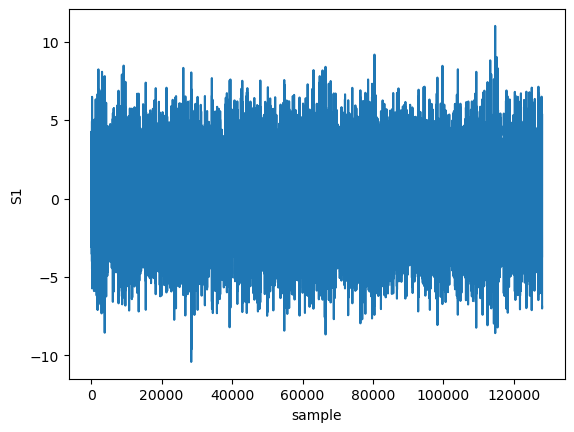

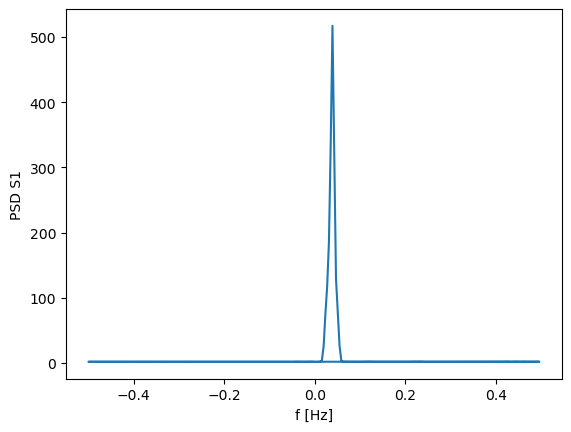

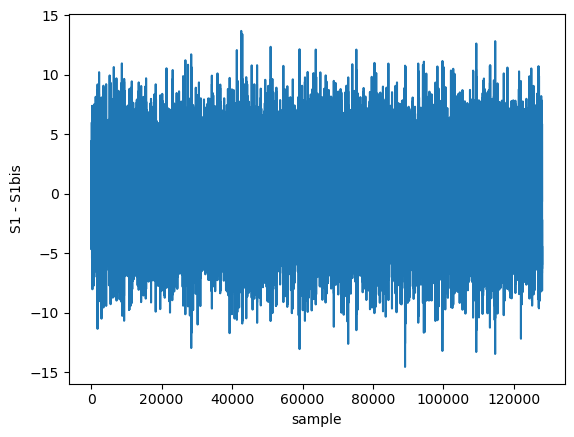

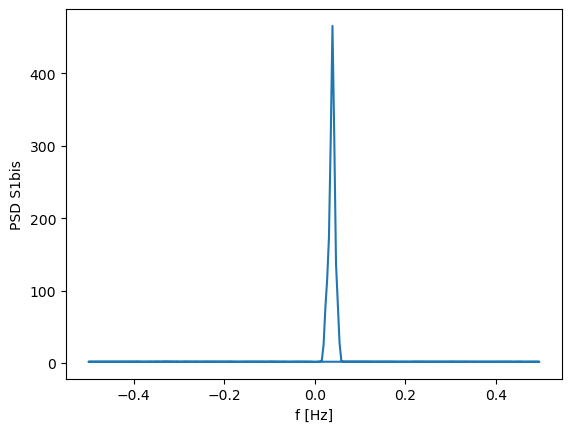

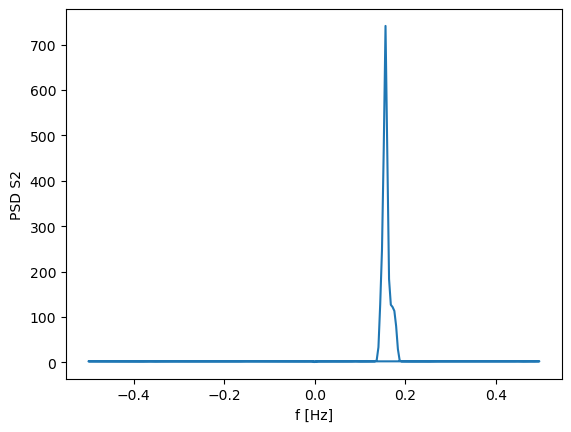

In [2]:
segment_length = 2**8
total_number_segments = 1000
psd_peak_strength = 10
# phase_noise_level = math.pi / 4.0
phase_noise_level = 2.0 * math.pi

real = False

# ------------------------------------
# f1, f2 below are FFT bin indices of a segment_length-point transform (fs = 1 Hz)

psd_1 = np.full((segment_length,), 1.0)
f1 = 10
mag_signal_f1 = psd_peak_strength
psd_1[f1-4:f1+4] = mag_signal_f1*5.0
psd_1[f1-2:f1+2] = mag_signal_f1*10.0
psd_1[f1] = mag_signal_f1*40.0
phase = None  # option 1: random phase
# phase = 15 * math.pi * np.full(psd_1.shape, 1.0)  # option 2: stochastic phase (rad)

signal_1 = generate_realization_from_PSD(psd=psd_1, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments, phase=phase, real=real, phase_noise_level=phase_noise_level)

plt.figure()
plt.plot(np.real(signal_1))
plt.ylabel("S1")
plt.xlabel("sample")
plt.show()

signal_1_welch_freq, signal_1_welch_psd = sp.signal.welch(signal_1, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_1_welch_freq, signal_1_welch_psd)
plt.ylabel("PSD S1")
plt.xlabel("f [Hz]")
plt.show()

# note that if you repeat, you get a similar but different PSD, as should be

signal_1_bis = generate_realization_from_PSD(psd=psd_1, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments, real=real)

plt.figure()
plt.plot(np.real(signal_1-signal_1_bis))
plt.ylabel("S1 - S1bis")
plt.xlabel("sample")
plt.show()

signal_1_welch_freq_bis, signal_1_welch_psd_bis = sp.signal.welch(signal_1_bis, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_1_welch_freq_bis, signal_1_welch_psd_bis)
plt.ylabel("PSD S1bis")
plt.xlabel("f [Hz]")
plt.show()

# ------------------------------------

psd_2 = np.full((segment_length,), 1.0)
f2 = 40
mag_signal_f2 = psd_peak_strength * 2
psd_2[f2-3:f2+7] = mag_signal_f2*3.0
psd_2[f2-2:f2+2] = mag_signal_f2*7.0
psd_2[f2] = mag_signal_f2*30.0
phase = None  # option 1: random phase
# phase = 40 * math.pi * np.full(psd_1.shape, 1.0)  # option 2: stochastic phase (rad)

signal_2 = generate_realization_from_PSD(psd=psd_2, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments, phase=phase, real=real, phase_noise_level=phase_noise_level)

if False:
    plt.figure()
    plt.plot(signal_2)
    plt.ylabel("S2")
    plt.show()

signal_2_welch_freq, signal_2_welch_psd = sp.signal.welch(signal_2, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_2_welch_freq, signal_2_welch_psd)
plt.ylabel("PSD S2")
plt.xlabel("f [Hz]")
plt.show()


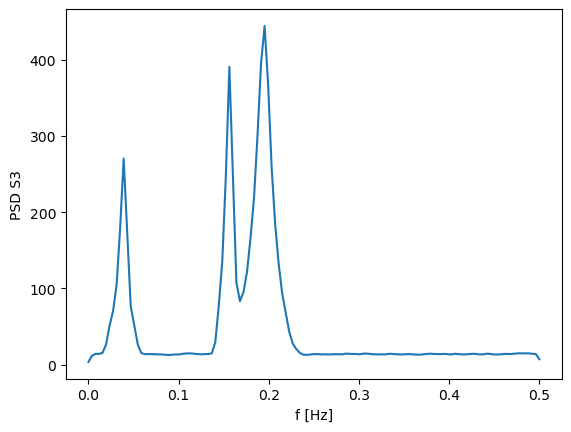

In [3]:
alpha = 0.5

phase_difference_harmonic_deg = 135.0
signal_3 = np.real(signal_1 + signal_2 + alpha * signal_1 * signal_2 * np.exp(-1j * phase_difference_harmonic_deg * math.pi / 180.0))

signal_3_welch_freq, signal_3_welch_psd = sp.signal.welch(signal_3, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_3_welch_freq, signal_3_welch_psd)
plt.ylabel("PSD S3")
plt.xlabel("f [Hz]")
plt.show()


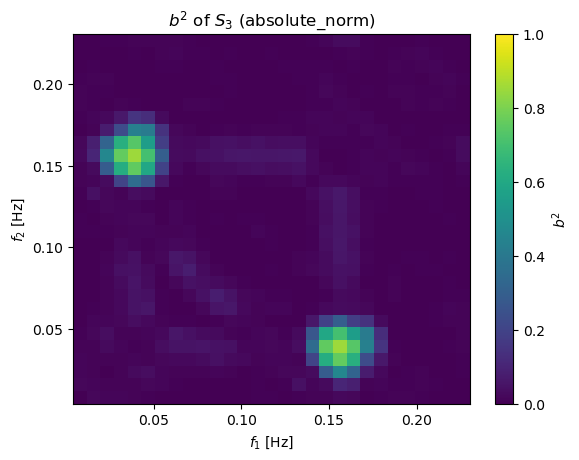

In [4]:
method = "absolute_norm"

f1_s3, f2_s3, ch_s3 = compute_auto_bicoherence(signal_3, sample_frequency=1.0, segment_length=segment_length//2, n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)
plot_b2(f1_s3, f2_s3, ch_s3, title=r"$b^2$ of $S_3$ (absolute_norm)")


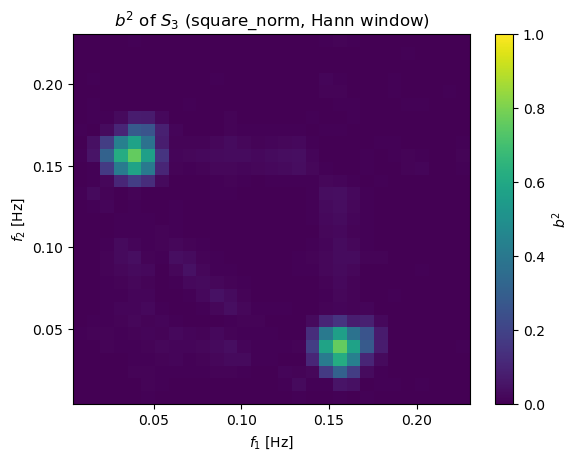

In [5]:
method = "square_norm"

f1_s3, f2_s3, ch_s3 = compute_auto_bicoherence(signal_3, sample_frequency=1.0, window=np.hanning, segment_length=segment_length//2, n_overlap=segment_length//8, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)
plot_b2(f1_s3, f2_s3, ch_s3, title=r"$b^2$ of $S_3$ (square_norm, Hann window)")


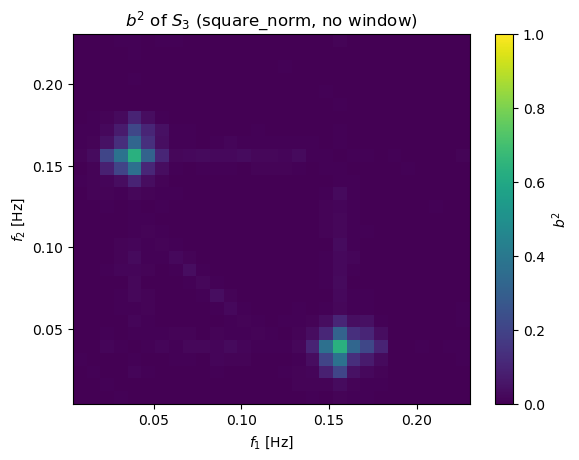

In [6]:
# note that a number of choices can influence the exact result - see for example here no window (None) instead of a Hanning one
# but the general result remains the same

method = "square_norm"

f1_s3, f2_s3, ch_s3 = compute_auto_bicoherence(signal_3, sample_frequency=1.0, window=None, segment_length=segment_length//2, n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)
plot_b2(f1_s3, f2_s3, ch_s3, title=r"$b^2$ of $S_3$ (square_norm, no window)")


## Compare with another package

In [7]:
from polycoherence import _plot_signal, polycoherence, plot_polycoherence

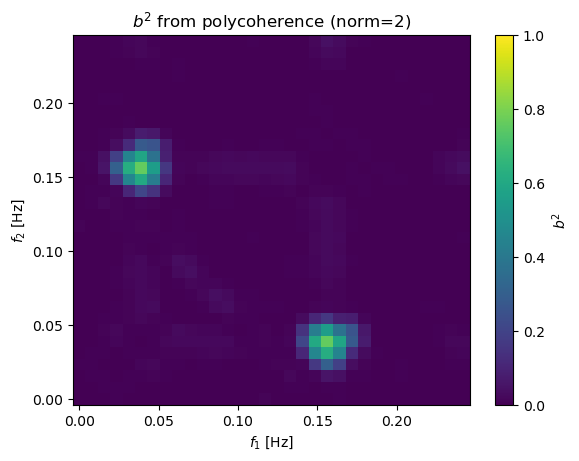

In [8]:
# polycoherence with norm=2 is Kim-Powers but returns the amplitude b = sqrt(b^2);
# square it so the map is b^2, consistent with the rest of this notebook
freq1, freq2, bicoh_amp = polycoherence(data=signal_3, fs=1.0, norm=2, window="hann", nperseg=segment_length//2, noverlap=segment_length//4, nfft=segment_length//2)
b2_poly = np.abs(bicoh_amp) ** 2

plt.figure()
plt.pcolormesh(freq2, freq1, b2_poly, shading="nearest", vmin=0.0, vmax=1.0)
plt.xlabel(r"$f_1$ [Hz]")
plt.ylabel(r"$f_2$ [Hz]")
plt.colorbar(label=r"$b^2$")
plt.title(r"$b^2$ from polycoherence (norm=2)")
plt.show()


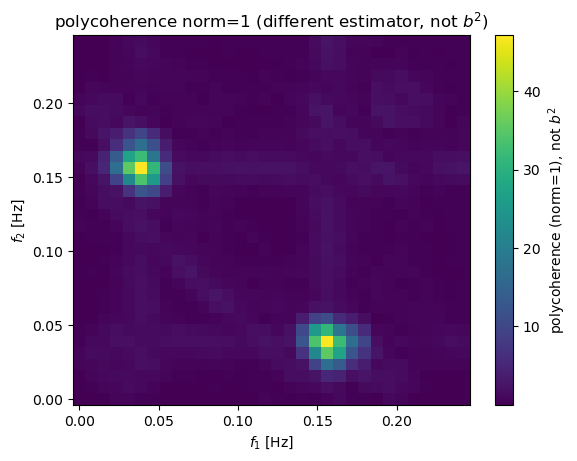

In [9]:
# polycoherence norm=1 is not the absolute-norm estimator above, and is not b^2;
# leave its native scale (often not in [0, 1])
freq1, freq2, bicoh_n1 = polycoherence(data=signal_3, fs=1.0, norm=1, window="hann", nperseg=segment_length//2, noverlap=segment_length//4, nfft=segment_length//2)

plt.figure()
plt.pcolormesh(freq2, freq1, np.abs(bicoh_n1), shading="nearest")
plt.xlabel(r"$f_1$ [Hz]")
plt.ylabel(r"$f_2$ [Hz]")
plt.colorbar(label=r"polycoherence (norm=1), not $b^2$")
plt.title("polycoherence norm=1 (different estimator, not $b^2$)")
plt.show()


### Look at the biphase

A high $b^2$ indicates that there is phase locking between the signal components at $f_1$, $f_2$ and $f_3$. The actual value of the phase $\mathrm{angle}(F(f_1) F(f_2) F^*(f_1+f_2))$ is provided by the biphase. See the docstring and code comments for more information about the ways to compute biphase with `compute_auto_biphase`; we recommend sticking to the `mean_then_angle` method, and masking points where $b^2$ is low (the biphase value is meaningful only where $b^2$ is large).

Note that the conventions in the initial problem being studied can easily change angles by 90 degrees and / or a + or - sign; make sure to check the consistency of the conventions used in the application and in the code.

Below, we illustrate the value of the biphase for the test signal $S_3$: observe the good match between the biphase blob at the location of the $b^2$ blob, and what was set in the synthetic signal $S_3$ generation above. Bins with $b^2$ below the mask threshold (a $b^2$ value, not an amplitude) are hidden. The 95% noise floor of $b^2$ under the null (true $b^2=0$) is also printed; the mask used for the figure is much higher, so that only the coupled peak remains.


segments p=1999, K=1982.3, dof=3964.6, null 95% b^2 floor=0.0015
biphase mask: b^2 > 0.36


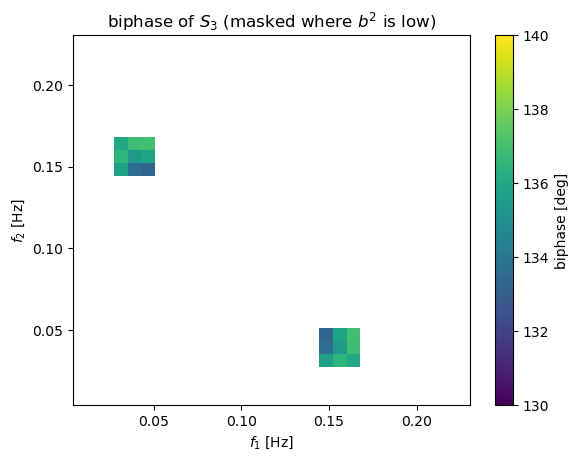

In [10]:
biphase_method = "mean_then_angle"
# biphase_method = "angle_then_mean"

low_bicoherence_threshold_method = "square_norm"

nperseg_b = segment_length // 2
noverlap_b = segment_length // 4
K, dof, p = estimate_bicoherence_edf(len(signal_3), nperseg_b, noverlap_b, window="hann")
b2_noise_95 = null_b2_threshold(K, p_false=0.05)
# illustration mask: keep only strong coupling (b^2), well above the null noise floor
hide_low_bicoherence_threshold = 0.36
print(f"segments p={p}, K={K:.1f}, dof={dof:.1f}, null 95% b^2 floor={b2_noise_95:.4f}")
print(f"biphase mask: b^2 > {hide_low_bicoherence_threshold}")

f1, f2, ph = compute_auto_biphase(
    signal_3, sample_frequency=1.0, window=np.hanning,
    segment_length=nperseg_b, n_overlap=noverlap_b,
    f1_range=[0.0, 0.22], f2_range=[0.0, 0.22],
    biphase_method=biphase_method,
    plot_distribution_peak=True,
    hide_low_bicoherence_threshold=hide_low_bicoherence_threshold,
    low_bicoherence_threshold_method=low_bicoherence_threshold_method,
)

plt.figure()
width_around_expected_deg = 5.0
plt.pcolormesh(
    f1, f2, np.transpose(ph) * 180.0 / math.pi, shading="nearest",
    vmin=phase_difference_harmonic_deg - width_around_expected_deg,
    vmax=phase_difference_harmonic_deg + width_around_expected_deg,
)
plt.xlabel(r"$f_1$ [Hz]")
plt.ylabel(r"$f_2$ [Hz]")
plt.colorbar(label="biphase [deg]")
plt.title(r"biphase of $S_3$ (masked where $b^2$ is low)")
plt.show()


### Look at the result with S3', same PSD but no cross term

$S_3'$ has nearly the same PSD (difference is rounding, stochasticity, etc) as $S_3$, but a very different bicoherence: no peak whatsoever in $b^2$, since the secondary peaks do not correspond to nonlinear terms, only to independent components. As a consequence, there is no significant $b^2$ anywhere.


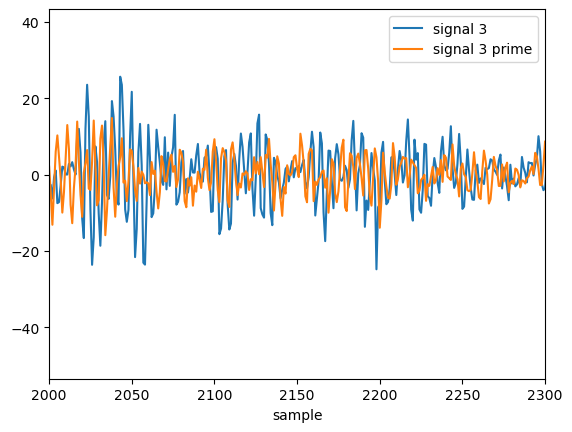

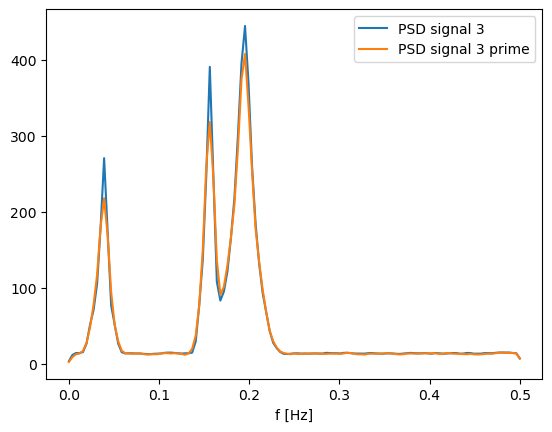

In [11]:
_, signal_3_welch_psd_2sided = sp.signal.welch(signal_3, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=False)
signal_3prime = generate_realization_from_PSD(psd=signal_3_welch_psd_2sided, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments)

plt.figure()
plt.plot(signal_3, label="signal 3")
plt.plot(signal_3prime, label="signal 3 prime")
start=2000
length=300
plt.xlim([start,start+length])
plt.xlabel("sample")
plt.legend()
plt.show()

signal_3prime_welch_freq, signal_3prime_welch_psd = sp.signal.welch(signal_3prime, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_3_welch_freq, signal_3_welch_psd, label="PSD signal 3")
plt.plot(signal_3prime_welch_freq, signal_3prime_welch_psd, label="PSD signal 3 prime")
plt.xlabel("f [Hz]")
plt.legend()
plt.show()


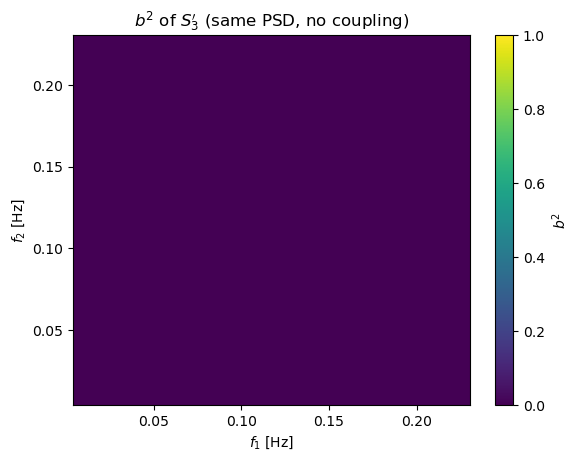

In [12]:
method = "square_norm"

f1_s3prime, f2_s3prime, ch_s3prime = compute_auto_bicoherence(signal_3prime, sample_frequency=1.0, segment_length=segment_length//2, n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)
plot_b2(f1_s3prime, f2_s3prime, ch_s3prime, title=r"$b^2$ of $S_3'$ (same PSD, no coupling)")


## Statistics of the bicoherence and biphase

This is a "physicist-like" summary of the sampling properties of the **estimators** $\hat{b}^2$ and $\hat{\beta}$. For a Gaussian process, the distribution, bias, and variance of these estimators can be given in terms of the true $b^2$ and the degrees of freedom. A simpler analogue (Welch PSD uncertainty) is in https://github.com/jerabaul29/tutorials/blob/main/uncertainty_gaussian_spectrum/uncertainty_gaussian_spectrum.ipynb .

Exact closed-form distributions are tricky; some formulae below are exact in a limit, others are accurate approximations (better as dof grows). The key reference is Elgar and Sebert, *Statistics of Bicoherence and Biphase*, JGR 94, 10,993–10,998 (1989), building on Haubrich (1965), Kim and Powers (1979), and others.

We write $b^2$ for the true value and $\hat{b}^2$ for the estimator returned by `compute_auto_bicoherence` (Kim–Powers `square_norm`). Elgar and Sebert call $b^2$ itself "the bicoherence".

### Distribution and statistics of $\hat{b}^2$

We use the same definition as the paper (their eq. 1) and as `square_norm`:

$$b^2(f_1, f_2) = \frac{\left| \sum_n B_n(f_1, f_2) \right|^2}{\left( \sum_n |F_n(f_1) F_n(f_2)|^2 \right) \left( \sum_n |F_n(f_1+f_2)|^2 \right)}$$

Notation: $K$ is the effective number of independent segments, and $\mathrm{dof} = 2K$ (Elgar and Sebert's dof: 256 non-overlapping records $\Rightarrow$ 512 dof).

#### Case 1: true $b^2 = 0$

The estimator never returns exactly 0, only a small positive noise value.

$2K\,\hat{b}^2$ follows a $\chi^2$ distribution with 2 degrees of freedom, so $\hat{b}^2$ is exponential / Gamma(shape $=1$, scale $=1/K$):

- mean $\mathbb{E}[\hat{b}^2] = 1/K = 2/\mathrm{dof}$ (this is also the bias)
- standard deviation $1/K$
- null 95% point: $P(\hat{b}^2 > x) \approx e^{-K x}$, so $x_{95} = -\ln(0.05)/K$ (`null_b2_threshold`)

The amplitude $\hat{b}=\sqrt{\hat{b}^2}$ is Rayleigh with $\sigma=1/\sqrt{2K}$ (mean $\sqrt{\pi/(4K)}$), but we do not use $\hat{b}$ elsewhere.

In this case the biphase is uniform on $[-\pi, \pi]$.

#### Effective $K$ with overlapping, windowed segments

Elgar and Sebert (1989) used **non-overlapping, untapered** records, so their $\mathrm{dof}=2N$ with $N$ the number of records. They do **not** give the overlap formula below.

For Welch-style overlapping windows, the analogue of the PSD equivalent-dof formula, with $\rho^3$ instead of $\rho^2$ because this is a third-order statistic, is:

$$K = \frac{p}{1 + 2 \sum_{m=1}^{p-1} (1 - m/p)\, \rho^3(mS)}$$

with $p$ the raw number of segments, $S$ the hop between consecutive window starts, and

$$\rho(mS) = \frac{\sum_n w[n]\, w[n+mS]}{\sum_n w[n]^2}$$

This is implemented in `estimate_bicoherence_edf`. The cube on $\rho$ (vs square for the periodogram) is the natural third-order extension of the window-correlation argument used for Welch spectra (see e.g. Percival & Walden for the second-order case, and Elgar and Guza, IEEE Trans. Acoust. Speech Signal Process. 36, 1667–1668, 1988, for bicoherence statistics with realistic records).

#### Case 2: true $b^2 \neq 0$

These results are semi-empirical (Monte Carlo in Elgar and Sebert). $\hat{b}^2$ is modeled as a scaled central chi-square $\alpha\chi^2_\nu$. If $X\sim\chi^2_\nu$ and $Y=\alpha X$, the density of $Y$ is

$$f_Y(y) = \frac{1}{\alpha}\, \frac{(y/\alpha)^{\nu/2-1} e^{-y/(2\alpha)}}{2^{\nu/2}\Gamma(\nu/2)}\, ,$$

with mean $\alpha\nu$ and variance $2\alpha^2\nu$, so

$$\alpha = \frac{\mathbb{E}[\hat{b}^2]}{\nu}\, ,\qquad \nu = \frac{2\mathbb{E}[\hat{b}^2]^2}{\mathrm{Var}[\hat{b}^2]}\, .$$

Empirically (their eqs. 4–5, 8):

$$\mathrm{Bias}[\hat{b}^2] = \frac{2}{\mathrm{dof}}(1-b^2)^2\, ,\qquad \mathrm{Var}[\hat{b}^2] = \frac{4 b^2}{\mathrm{dof}}(1-b^2)^3\, ,\qquad \nu \approx \frac{\mathrm{dof}\, b^2}{2(1-b^2)^3}\, .$$

The biphase estimator is approximately Gaussian, unbiased, with variance (radians$^2$; their eq. 9)

$$\mathrm{Var}(\hat{\beta}) = \frac{1}{\mathrm{dof}}\left(\frac{1}{b^2}-1\right)\, .$$


## Appendix: bicoherence and biphase with confidence bounds

`compute_bicoherence_with_confidence` (in `bicoherence_edf.py`) ties together everything above into a single call: given the usual signal / segmentation / windowing arguments (like `compute_auto_bicoherence`) plus a `confidence` level (default 95%) and a `bicoherence_threshold` (default 0.4), it computes the b^2 and biphase point estimates, the effective number of independent segments K and dof, and returns:

- `bicoherence_likely_zero`: a boolean map, `True` where b^2 is not significantly different from 0 at the given confidence,
- `(bicoherence_lower, bicoherence_upper)`: a pair of b^2 maps, both 0 where `bicoherence_likely_zero` is `True`, otherwise the confidence bounds on b^2,
- `(biphase_lower, biphase_upper)`: a pair of biphase maps (rad), both NaN wherever `bicoherence_likely_zero` is `True`, wherever the b^2 point estimate is at or below `bicoherence_threshold` (a plain display cutoff, not a statistical test — the biphase is only meaningful where b^2 is reasonably high), or wherever the biphase confidence interval half-width is >= pi (the interval then wraps all the way around the circle and is uninformative); otherwise the confidence bounds.

It also prints a short summary while it runs: the raw and effective (independent) number of segments, the dof, the null b^2 threshold used for the "likely zero" test, and the fraction of bins where the biphase ends up hidden.


compute_bicoherence_with_confidence: n_total=128000, segment_length=128, n_overlap=64
    raw (non-independent) segments p=1999
    effective independent segments K=1982.32, dof=2K=3964.64
    confidence=95.0%  ->  null b^2 threshold=0.001511
    fraction of bins with b^2 likely 0 at this confidence: 33.1%
    biphase hidden (b^2 likely 0, b^2 <= 0.36, or CI wraps around): 97.9% of bins


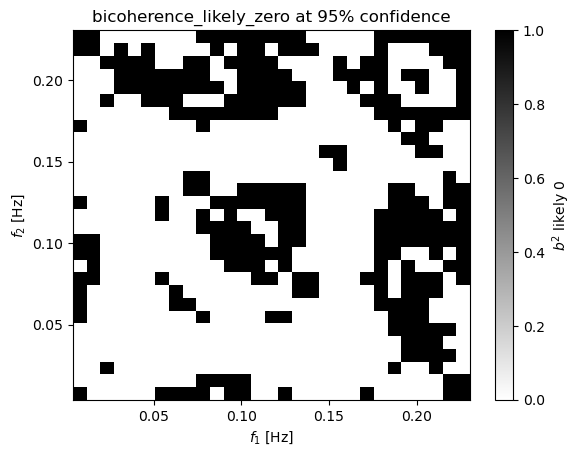

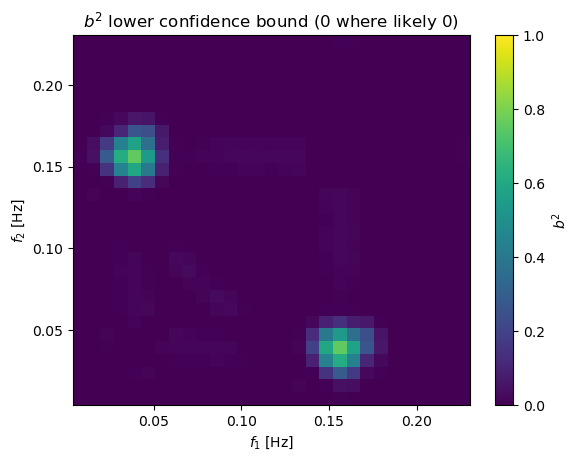

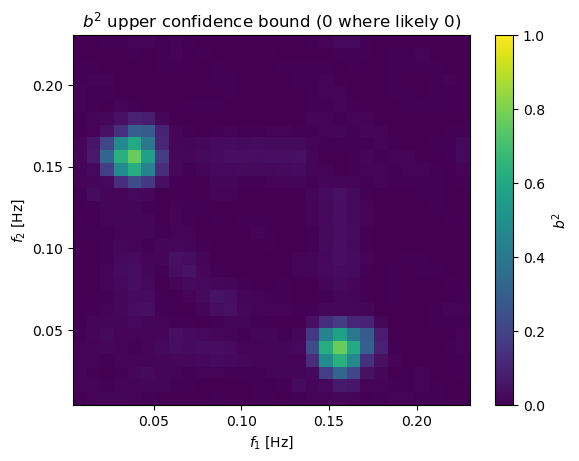

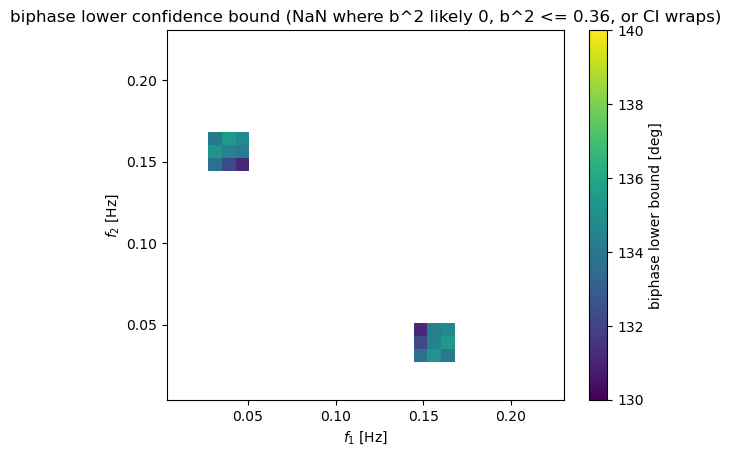

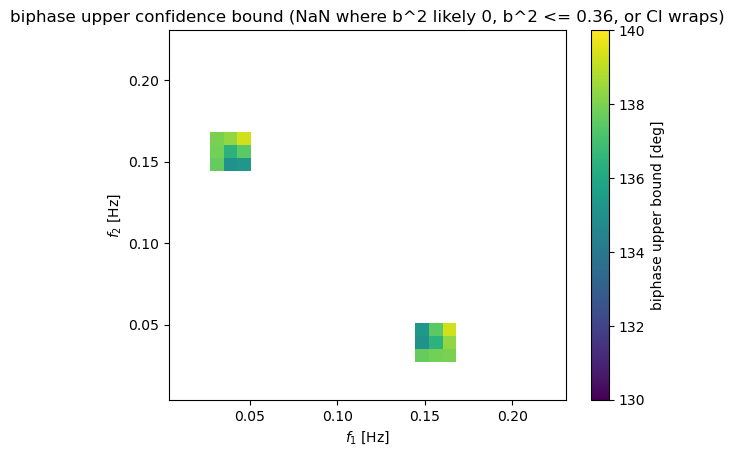

In [14]:
from bicoherence_edf import compute_bicoherence_with_confidence

confidence = 0.95
bicoherence_threshold = 0.36

(
    f1_conf, f2_conf,
    b2_hat, biphase_hat,
    bicoherence_likely_zero,
    (b2_lower, b2_upper),
    (biphase_lower, biphase_upper),
) = compute_bicoherence_with_confidence(
    signal_3, sample_frequency=1.0,
    segment_length=segment_length//2, n_overlap=segment_length//4,
    f1_range=[0.0, 0.22], f2_range=[0.0, 0.22],
    confidence=confidence,
    bicoherence_threshold=bicoherence_threshold,
)

plt.figure()
plt.pcolormesh(f1_conf, f2_conf, np.transpose(bicoherence_likely_zero), shading="nearest", cmap="gray_r", vmin=0, vmax=1)
plt.xlabel(r"$f_1$ [Hz]")
plt.ylabel(r"$f_2$ [Hz]")
plt.colorbar(label=r"$b^2$ likely 0")
plt.title(f"bicoherence_likely_zero at {100 * confidence:.0f}% confidence")
plt.show()

plot_b2(f1_conf, f2_conf, b2_lower, title=r"$b^2$ lower confidence bound (0 where likely 0)")
plot_b2(f1_conf, f2_conf, b2_upper, title=r"$b^2$ upper confidence bound (0 where likely 0)")

width_around_expected_deg = 5.0
plt.figure()
plt.pcolormesh(
    f1_conf, f2_conf, np.transpose(biphase_lower) * 180.0 / math.pi, shading="nearest",
    vmin=phase_difference_harmonic_deg - width_around_expected_deg,
    vmax=phase_difference_harmonic_deg + width_around_expected_deg,
)
plt.xlabel(r"$f_1$ [Hz]")
plt.ylabel(r"$f_2$ [Hz]")
plt.colorbar(label="biphase lower bound [deg]")
plt.title(f"biphase lower confidence bound (NaN where b^2 likely 0, b^2 <= {bicoherence_threshold}, or CI wraps)")
plt.show()

plt.figure()
plt.pcolormesh(
    f1_conf, f2_conf, np.transpose(biphase_upper) * 180.0 / math.pi, shading="nearest",
    vmin=phase_difference_harmonic_deg - width_around_expected_deg,
    vmax=phase_difference_harmonic_deg + width_around_expected_deg,
)
plt.xlabel(r"$f_1$ [Hz]")
plt.ylabel(r"$f_2$ [Hz]")
plt.colorbar(label="biphase upper bound [deg]")
plt.title(f"biphase upper confidence bound (NaN where b^2 likely 0, b^2 <= {bicoherence_threshold}, or CI wraps)")
plt.show()
